In [1]:
# Detecting compatibility of scipy and quimb versions
import scipy
import quimb
print(scipy.__version__)
print(quimb.__version__)

%config InlineBackend.figure_formats = ['svg']

import quimb as qu
import quimb.tensor as qtn

import numpy as np
# coefficient \lambda
single_qubit_noise = np.log(- 0.002 * 2 + 1) * (-0.5)
two_qubit_noise = np.log(- 0.0002 * 2 + 1) * (-0.5)

noise_level = 64

# probabilities of error 1-\omega
w_1 = (1 - np.exp(- 2 * noise_level * single_qubit_noise) ) / 2
w_2 = (1 - np.exp(- 2 * noise_level * two_qubit_noise) ) / 2
print(w_1, w_2)

1.15.2
1.11.2
0.11312767502213678 0.0126400451540703


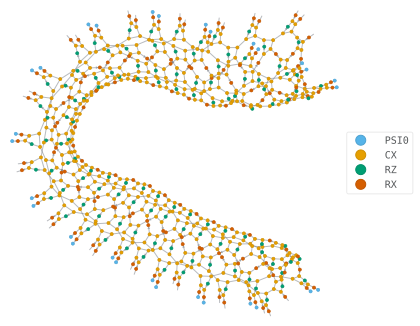

<Circuit(n=30, num_gates=498, gate_opts={'contract': 'auto-split-gate', 'propagate_tags': 'register'})>

In [7]:
import numpy as np
# I found that this random generator needs "numpy version >=2.0" to work properly
seed = 43
np.random.seed(seed)

# 20 qubits and tag the initial wavefunction tensors
N = 30
J = 0.5     # 相互作用强度
h = 1.0     # 横场强度
t = 1     # 演化时间
r = 4   # trotter步数

z_angle = - J * t / r
x_angle = - h * t / r

# coefficient \lambda
single_qubit_noise = np.log(- 0.02 * 2 + 1) * (-0.5)
two_qubit_noise = np.log(- 0.002 * 2 + 1) * (-0.5)

noise_level = 0

# probabilities of error 1-\omega
w_1 = (1 - np.exp(- 2 * noise_level * single_qubit_noise) ) / 2
w_2 = (1 - np.exp(- 2 * noise_level * two_qubit_noise) ) / 2

circ = qtn.Circuit(N)

# initial layer of hadamards
for i in range(N):
    circ.apply_gate('RX', x_angle, i) # , gate_round=0)

# 8 rounds of entangling gates
for j in range(1, r+1):

    # ZZ rotations on even pairs
    for i in range(0, N-1, 2):
        # slower: circ.apply_gate('RZZ', 2 * z_angle, i, i+1)
        circ.apply_gate('CX', i, i + 1) # , gate_round=j)
        circ.apply_gate('RZ', 2 * z_angle, i+1) # , gate_round=j)
        circ.apply_gate('CX', i, i + 1) # , gate_round=j)
        
    # ZZ rotations odd pairs
    for i in range(1, N-1, 2):
        # slower: circ.apply_gate('RZZ', 2 * z_angle, i, i+1)
        circ.apply_gate('CX', i, i + 1) # , gate_round=j)
        circ.apply_gate('RZ', 2 * z_angle, i+1) # , gate_round=j)
        circ.apply_gate('CX', i, i + 1) # , gate_round=j)

    # X rotations
    if j < r:
        for i in range(N):
            circ.apply_gate('RX', 2 * x_angle, i) # , gate_round=j)
    else:
        for i in range(N):
            circ.apply_gate('RX', x_angle, i) # , gate_round=j+1)


# plot
# circ.psi.draw(color=['PSI0', 'RZZ', 'RZ', 'RX'])
circ.psi.draw(color=['PSI0', 'CX', 'RZ', 'RX'])

if 0:
    for g in circ.gates:
        print(g)
circ

In [8]:
%%time
from pathlib import Path
import json

# collect the 8 samples (seeded for reproducibility)
samples = list(circ.sample(1000, seed=seed))

# ensure output directory exists and write JSON
out_path = Path(f'sample_results_N_{N}') / f'r_{r}_noise_{noise_level}_seed_{seed}.json'
out_path.parent.mkdir(parents=True, exist_ok=True)

if out_path.exists():
    raise FileExistsError(f'File {out_path} already exists!')

with out_path.open('w') as f:
    json.dump(samples, f, indent = 1)
        
print(f'Saved {len(samples)} samples to {out_path}')

# compute the observable value from a bitstring
def sum_Z(bitstring):
    return sum((1 - 2 * int(b) ) for b in bitstring)

observable = 0
for sample in samples:
    observable += sum_Z(sample) / len(samples)
    
print('Estimated <sum Z> = ', observable)

# store the observable value into numpy file
obs_path = Path(f'sample_results_N_{N}') / f'r_{r}_noise_{noise_level}_seed_{seed}.txt'
with obs_path.open('w') as f:
    f.write(f'Estimated <sum Z> = {observable}\n')

Saved 1000 samples to sample_results_N_30/r_4_noise_0_seed_43.json
Estimated <sum Z> =  4.633999999999969
CPU times: user 28.9 s, sys: 363 ms, total: 29.2 s
Wall time: 29.1 s


In [17]:
# store the observable value into numpy file
obs_path = Path(f'sample_results_N_{N}') / f'r_{r}_noise_{noise_level}_seed_{seed}.npy'
with obs_path.open('wb') as f:
    np.save(f, np.array([observable]))

In [24]:
%%time
# sample it a few times and count frequencies (existing code)
from collections import Counter

observable = 0
samples = list(circ.sample(1000, seed=42))
counts = Counter(samples)

if 0:
    print('Counts (most common first):')
    for outcome, cnt in counts.most_common():
        print(f"{outcome}: {cnt}")

print('\nProbabilities:')
total = sum(counts.values())
for outcome, cnt in counts.most_common():
    print(f"{outcome}: {cnt/total:.4f}")
    observable += cnt * sum_Z(outcome) / total
    
print(observable)


Probabilities:
1111111111: 0.0190
1001111111: 0.0090
1111111011: 0.0090
0001111111: 0.0080
1111111001: 0.0080
0111111111: 0.0080
1110001111: 0.0070
1000111111: 0.0070
1111100111: 0.0070
1111111110: 0.0070
1011111101: 0.0060
1011111100: 0.0060
1100001111: 0.0060
1111101111: 0.0060
0111110011: 0.0060
1111110000: 0.0060
0110011111: 0.0060
1101111111: 0.0060
1001100111: 0.0050
1111000111: 0.0050
1011111111: 0.0050
1100000111: 0.0050
1100111111: 0.0050
1111110001: 0.0050
1111110101: 0.0050
1111011111: 0.0050
1111001111: 0.0050
1000001111: 0.0050
1110111101: 0.0050
1111001100: 0.0050
1111110010: 0.0040
0011111111: 0.0040
1111111100: 0.0040
1101111100: 0.0040
1110111111: 0.0040
0011000011: 0.0040
1110110000: 0.0040
1110011111: 0.0040
1110110011: 0.0040
1111101110: 0.0040
1111101011: 0.0040
1111011001: 0.0040
1100000011: 0.0040
0011100111: 0.0040
1110100011: 0.0040
1110111110: 0.0040
0001111101: 0.0040
0000001111: 0.0040
1110111011: 0.0040
0111001111: 0.0040
1111010011: 0.0040
0111011111: 0.0

In [ ]:
from pathlib import Path
import json
out_path = Path(f'noise_{noise_level}_seed_{seed}.json')
out_path.mkdir()

In [ ]:
from scipy.linalg import expm
from scipy.linalg import norm
import numpy as np

# 参数
n = 20     # 自旋数
J = 0.5     # 相互作用强度
h = 1.0     # 横场强度
t = 1     # 演化时间

# 定义 Pauli 矩阵
X = np.array([[0, 1], [1, 0]])  # Pauli-X 矩阵
Y = np.array([[0, -1j], [1j, 0]])  # Pauli-Y 矩阵
Z = np.array([[1, 0], [0, -1]])  # Pauli-Z 矩阵
I = np.eye(2)  # 单位矩阵


# 生成五比特的 Ising 模型哈密顿量
def ising_hamiltonian(num_bits, J=0.5, h=1):
    H1 = np.zeros((2**num_bits, 2**num_bits), dtype=complex)
    H2 = np.zeros((2**num_bits, 2**num_bits), dtype=complex)
    H3 = np.zeros((2**num_bits, 2**num_bits), dtype=complex)
    
    # 添加最近邻自旋的交互作用 (σz σz)
    for i in range(0, num_bits - 1, 2):  # 只考虑相邻自旋，不包含周期性边界
        # 生成针对 (i, i+1) 对的 σz σz 交互项
        # Heisenberg 模型的交互作用项可以是 σx σx, σy σy 或 σz σz
        interaction_term = np.kron(np.eye(2**i), np.kron(np.kron(Z, Z), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(X, X), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(Y, Y), np.eye(2**(num_bits-i-2))))
        H3 += -J * interaction_term
    
    for i in range(1, num_bits - 1, 2):
        # 生成针对 (i, i+1) 对的 σz σz 交互项
        interaction_term = np.kron(np.eye(2**i), np.kron(np.kron(Z, Z), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(X, X), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(Y, Y), np.eye(2**(num_bits-i-2))))
        H2 += -J * interaction_term
        
    # 添加外部磁场项 (σx)s
    for i in range(num_bits):
        field_term = np.kron(np.eye(2**i), np.kron(X, np.eye(2**(num_bits-i-1))))
        H1 += -h * field_term
        
    return H1, H2, H3, H1 + H2 + H3

H1, H2, H3, H = ising_hamiltonian(n, J, h)
U = expm(-1j * H * t)

initial_state = np.zeros(2**n, dtype=complex)
initial_state[0] = 1.0  # 全部自旋向上态



: 